<a href="https://colab.research.google.com/github/prithviemmidi/LifeSatisfactionAnalysis/blob/main/Decision_Tree_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [541]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import io
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.tree import plot_tree
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [542]:
path = "/content/drive/MyDrive/lifesat_csv.csv"
df_old = pd.read_csv(path)
df_old.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,member34,othersize,pomst,agesq,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid
0,68035365,45,1981.589,1,0,0,0,0,0,1,...,0,0,0.00000,2025,1.134772,1.7147,1.33485,0.318156,-0.471428,1
1,68035365,46,2110.081,1,0,0,0,0,0,1,...,0,0,33.33333,2116,1.134772,1.7147,1.33485,0.318156,-0.471428,2
2,68035365,46,2351.826,1,0,0,0,0,0,1,...,0,0,66.66666,2116,1.134772,1.7147,1.33485,0.318156,-0.471428,3
3,68035365,48,2219.140,1,0,0,0,0,0,1,...,0,0,66.66666,2304,1.134772,1.7147,1.33485,0.318156,-0.471428,4
4,68035365,49,2498.854,1,0,0,0,0,0,1,...,0,0,50.00000,2401,1.134772,1.7147,1.33485,0.318156,-0.471428,5


aggregate rules

In [543]:
edu_cols = ['neduc','ueduc','oheduc','Alevel','gcse','otheduc']
marital_cols = ['single','married','others']
employment_cols = ['selfemploy','employed','unemploy','retired','sick','familycare','student']
household_cols = ['onemember','twomember','member34','othersize']
trait_cols = [
    'openness_std','neuroticism_std','agreeableness_std',
    'extraversion_std','conscientiousness_std']

In [544]:
agg_rules = {}

for col in df_old.columns:
    if col == 'pidp':
        continue
    elif col in ['male'] + trait_cols:
        agg_rules[col] = 'first'
    elif col in edu_cols:
        agg_rules[col] = 'max'
    else:
        agg_rules[col] = 'mean'

df = df_old.groupby('pidp').agg(agg_rules).reset_index()

print(f"Original rows in df_old: {len(df_old)}")
print(f"Unique individuals in df: {len(df)}")

Original rows in df_old: 25128
Unique individuals in df: 1047




```
Sorting into categorical variables
```



In [545]:
df["genders"] = df["male"].map({0: "Female", 1: "Male"})
df['marital_status'] = df[['single','married','others']].idxmax(axis=1)
df['employment_status'] = df[['selfemploy','employed','unemploy','retired','sick','familycare','student']].idxmax(axis=1)
df['household_size'] = df[['onemember','twomember','member34','othersize']].idxmax(axis=1)

In [546]:
df['education'] = df[['neduc','ueduc','oheduc','Alevel','gcse','otheduc']].idxmax(axis=1)
education_labels = {
    'neduc': 'None',
    'gcse': 'GCSE',
    'Alevel': 'A-level',
    'otheduc': 'Other ',
    'ueduc': 'University',
    'oheduc': 'Other Higher'}
df['education'] = df['education'].map(education_labels)

In [547]:
traits = [
    'openness_std',
    'neuroticism_std',
    'agreeableness_std',
    'extraversion_std',
    'conscientiousness_std']

In [548]:
df.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid,genders,marital_status,employment_status,household_size,education
0,68035365,57.041667,2493.496375,1,0,0,0,0,0,1,...,1.714700,1.334850,0.318156,-0.471428,12.5,Male,others,employed,onemember,Other
1,68058485,64.291667,4008.875375,1,0,0,0,0,1,0,...,1.714700,-0.626826,-0.449034,-0.471428,12.5,Male,married,retired,twomember,GCSE
2,68058489,64.291667,4008.875375,0,0,0,0,0,0,1,...,0.315594,-0.626826,-0.449034,-0.471428,12.5,Female,married,retired,twomember,Other
3,68064609,57.291667,4231.804125,0,0,0,0,0,1,0,...,-0.383959,1.334850,1.085346,1.368915,12.5,Female,married,employed,twomember,GCSE
4,68097245,58.791667,1964.208062,0,0,0,0,0,1,0,...,1.015147,0.354012,1.852535,-0.471428,12.5,Female,others,employed,onemember,GCSE


In [549]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pidp                   1047 non-null   int64  
 1   agenew                 1047 non-null   float64
 2   incomecpi              1047 non-null   float64
 3   male                   1047 non-null   int64  
 4   neduc                  1047 non-null   int64  
 5   ueduc                  1047 non-null   int64  
 6   oheduc                 1047 non-null   int64  
 7   Alevel                 1047 non-null   int64  
 8   gcse                   1047 non-null   int64  
 9   otheduc                1047 non-null   int64  
 10  single                 1047 non-null   float64
 11  married                1047 non-null   float64
 12  others                 1047 non-null   float64
 13  selfemploy             1047 non-null   float64
 14  employed               1047 non-null   float64
 15  unem

In [550]:
df.describe()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,member34,othersize,pomst,agesq,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid
count,1.047000e+03,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,...,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.0
mean,4.254653e+08,52.281797,4085.248531,0.436485,0.115568,0.233047,0.134670,0.241643,0.313276,0.119389,...,0.393545,0.059296,70.675476,2915.440823,-0.007413,-0.018481,-0.050689,-0.013047,0.048860,12.5
std,2.434545e+08,11.194397,2062.525185,0.496186,0.319859,0.422974,0.341534,0.428283,0.464047,0.324400,...,0.343424,0.158099,12.384463,1189.712462,0.947431,0.970993,0.968454,0.993709,0.919850,0.0
min,6.803536e+07,29.833333,696.105387,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,15.277780,947.500000,-2.727849,-1.783065,-4.550178,-2.750603,-3.231943,12.5
25%,2.053444e+08,43.791667,2680.394821,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.041667,0.000000,63.888889,1976.208333,-0.410277,-1.083512,-0.626826,-0.449034,-0.471428,12.5
50%,4.097122e+08,51.791667,3806.917375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.333333,0.000000,72.916665,2740.875000,0.362247,-0.383959,0.354012,0.318156,0.448744,12.5
75%,6.154190e+08,60.791667,4980.267125,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.708333,0.000000,79.166670,3754.125000,0.362247,0.315594,0.354012,0.318156,0.448744,12.5
max,8.200304e+08,83.875000,18702.897917,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,97.916668,7095.041667,1.907296,2.414253,1.334850,1.852535,1.368915,12.5


life satisfaction analysis

In [551]:
df['pomst'].describe()

,pomst
count,1047.000000
mean,70.675476
std,12.384463
min,15.277780
25%,63.888889
50%,72.916665
75%,79.166670
max,97.916668


In [552]:
pomst_table = df['pomst'].value_counts()
pomst_table

,count
pomst,
79.166670,11
81.250005,9
80.555560,9
78.472225,8
81.250004,8
...,...
83.333338,1
70.833336,1
73.611113,1


Coding decision tree

In [553]:
features = traits + ['male']
target = 'pomst'

In [554]:
df_tree = df[features + [target]].dropna()

In [555]:
df_tree.head()

,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,male,pomst
0,1.134772,1.714700,1.334850,0.318156,-0.471428,1,40.972220
1,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,1,58.333329
2,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,0,78.472226
3,0.362247,-0.383959,1.334850,1.085346,1.368915,0,61.111114
4,1.134772,1.015147,0.354012,1.852535,-0.471428,0,65.972222


decision tree

In [556]:
# Prepare X and y
X = df_tree[features]
y = df_tree[target]

Step 1: Growing Tree

In [557]:
tree_model = dtr(min_samples_leaf=75, criterion='squared_error', splitter='best',random_state=17)
tree_model.fit(X, y)

DecisionTreeRegressor(min_samples_leaf=75, random_state=17)

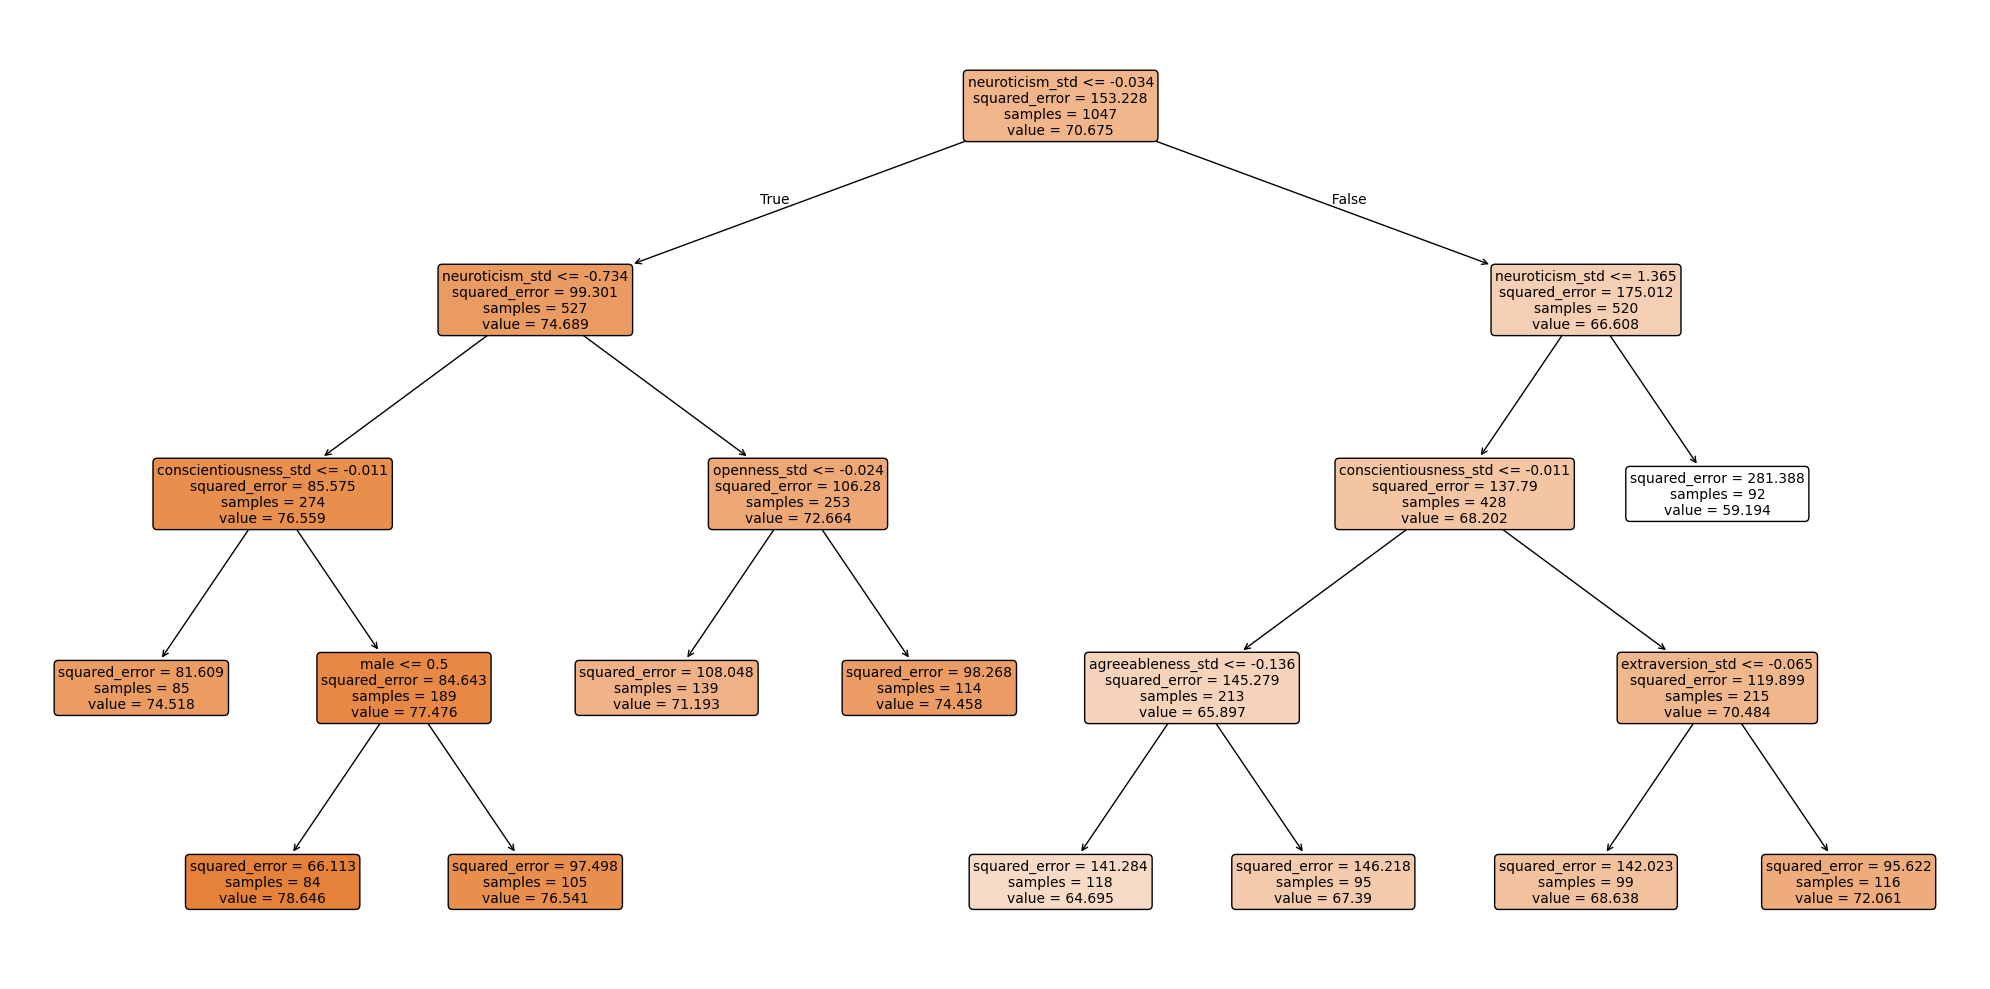

In [558]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=features,
          filled=True,
          rounded=True,
          fontsize=10)
plt.tight_layout()

In [559]:
print("Feature Importance:")
for feat, imp in zip(features, tree_model.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.022
  neuroticism_std: 0.844
  agreeableness_std: 0.013
  extraversion_std: 0.021
  conscientiousness_std: 0.093
  male: 0.007


Assigning each terminal node to a dummy variable

In [560]:
terminal_indices = tree_model.apply(X)

In [561]:
print(f"# of observations: {len(terminal_indices)}")
print(f"Each unique terminal node: {np.unique(terminal_indices)}")
print(f"# of terminal nodes: {tree_model.get_n_leaves()}")

# of observations: 1047
Each unique terminal node: [ 3  5  6  8  9 13 14 16 17 18]
# of terminal nodes: 10


In [562]:
df['terminal_node'] = terminal_indices

In [563]:
terminal_dummies = pd.get_dummies(df['terminal_node'], prefix='leaf')
df = pd.concat([df, terminal_dummies], axis=1)

In [564]:
df.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,leaf_3,leaf_5,leaf_6,leaf_8,leaf_9,leaf_13,leaf_14,leaf_16,leaf_17,leaf_18
0,68035365,57.041667,2493.496375,1,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True
1,68058485,64.291667,4008.875375,1,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,True
2,68058489,64.291667,4008.875375,0,0,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
3,68064609,57.291667,4231.804125,0,0,0,0,0,1,0,...,False,False,False,False,True,False,False,False,False,False
4,68097245,58.791667,1964.208062,0,0,0,0,0,1,0,...,False,False,False,False,False,False,True,False,False,False


merging the terminal nodes back to the full df (df_old)

In [565]:
df_old = df_old.merge(df[['pidp', 'terminal_node']], on='pidp', how='left')

**running** fixed effect regression within the full dataset

In [566]:
for i, leaf in enumerate(sorted(df_old['terminal_node'].unique()), start=1):
    subgroup = df_old[df_old['terminal_node'] == leaf]
    y_leaf = subgroup['pomst']
    X_leaf = sm.add_constant(subgroup['incomecpi'])

    model = smf.ols('pomst ~ incomecpi + C(pidp)', data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']})

    print(f"\nSubtree {i} (leaf {leaf})")
    print("Number of individuals:", subgroup['pidp'].nunique())
    print("Number of observations:", len(subgroup))
    print(model.summary())


Subtree 1 (leaf 3)
Number of individuals: 85
Number of observations: 2040
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     1.888
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.173
Time:                        10:30:47   Log-Likelihood:                -8467.3
No. Observations:                2040   AIC:                         1.711e+04
Df Residuals:                    1954   BIC:                         1.759e+04
Df Model:                          85                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 84, but rank is 1
  warnings.warn('covariance of constraints does not have full '



Subtree 3 (leaf 6)
Number of individuals: 105
Number of observations: 2520
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     23.02
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           5.37e-06
Time:                        10:30:47   Log-Likelihood:                -10740.
No. Observations:                2520   AIC:                         2.169e+04
Df Residuals:                    2414   BIC:                         2.231e+04
Df Model:                         105                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 105, but rank is 1
  warnings.warn('covariance of constraints does not have full '



Subtree 4 (leaf 8)
Number of individuals: 139
Number of observations: 3336
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     11.61
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           0.000858
Time:                        10:30:48   Log-Likelihood:                -14186.
No. Observations:                3336   AIC:                         2.865e+04
Df Residuals:                    3196   BIC:                         2.951e+04
Df Model:                         139                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 99, but rank is 1
  warnings.warn('covariance of constraints does not have full '



Subtree 9 (leaf 17)
Number of individuals: 116
Number of observations: 2784
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     34.52
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           4.20e-08
Time:                        10:30:49   Log-Likelihood:                -11785.
No. Observations:                2784   AIC:                         2.380e+04
Df Residuals:                    2667   BIC:                         2.450e+04
Df Model:                         116                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 116, but rank is 1
  warnings.warn('covariance of constraints does not have full '



Subtree 10 (leaf 18)
Number of individuals: 92
Number of observations: 2208
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     582.9
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           2.43e-41
Time:                        10:30:50   Log-Likelihood:                -9481.4
No. Observations:                2208   AIC:                         1.915e+04
Df Residuals:                    2115   BIC:                         1.968e+04
Df Model:                          92                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 92, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [567]:
for leaf in sorted(df_old['terminal_node'].unique()):
    subgroup = df_old[df_old['terminal_node'] == leaf]

    model = smf.ols('pomst ~ incomecpi + C(pidp)', data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']}
    )

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))
    print("Income coef:", model.params['incomecpi'])
    print("Std err:", model.bse['incomecpi'])
    print("p-value:", model.pvalues['incomecpi'])


Leaf 3
Individuals: 85
Observations: 2040
Income coef: -0.00013714576790565538
Std err: 0.0003340854678188565
p-value: 0.6814311174696038

Leaf 5
Individuals: 84
Observations: 2016
Income coef: -0.0002393505944106825
Std err: 0.00027514320360199544
p-value: 0.38434806031190816

Leaf 6
Individuals: 105
Observations: 2520
Income coef: 0.00017949380712614443
Std err: 0.00026390102938234994
p-value: 0.49640583649719994

Leaf 8
Individuals: 139
Observations: 3336
Income coef: -0.0005979745258240165
Std err: 0.0002965358302218479
p-value: 0.04374418706243978

Leaf 9
Individuals: 114
Observations: 2736
Income coef: 3.4340678014997607e-06
Std err: 7.095990499824774e-05
p-value: 0.9614018573706262

Leaf 13
Individuals: 118
Observations: 2832
Income coef: -0.000284191627049616
Std err: 0.00026997009264508585
p-value: 0.2924885102467648

Leaf 14
Individuals: 95
Observations: 2280
Income coef: -9.529134137182124e-05
Std err: 0.00016997727784137702
p-value: 0.5750619100017773

Leaf 16
Individuals:

adding age, square of age and marital status then estimating a model for each tree to examine relationship between life satisfaction and income

In [568]:
for i, leaf in enumerate(sorted(df_old['terminal_node'].dropna().unique()), start=1):
    subgroup = df_old[df_old['terminal_node'] == leaf].copy()

    regression_new = 'pomst ~ incomecpi + agenew + agesq + single + married + others + C(pidp)'
    model = smf.ols(regression_new , data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']})

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))

    print("Income coef:", model.params['incomecpi'])
    print("Age coef:", model.params['agenew'])
    print("Age^2 coef:", model.params['agesq'])
    print("Single coef:", model.params['single'])
    print("Married coef:", model.params['married'])
    print("Others coef:", model.params['others'])

    print("Income Std err:", model.bse['incomecpi'])
    print("Income p-value:", model.pvalues['incomecpi'])


Leaf 3
Individuals: 85
Observations: 2040
Income coef: -9.832077526774659e-05
Age coef: 0.44878574032208257
Age^2 coef: -0.00287701055449227
Single coef: 12.734466117931698
Married coef: 14.536522759928951
Others coef: 13.582292396912756
Income Std err: 0.00034426745435508534
Income p-value: 0.7751889750534353

Leaf 5
Individuals: 84
Observations: 2016
Income coef: -0.0003255260004505963
Age coef: 0.0018606154731403701
Age^2 coef: -0.00018640469768725957
Single coef: 21.25107187898076
Married coef: 22.587682590775355
Others coef: 18.404686688718762
Income Std err: 0.00026702478101659264
Income p-value: 0.2228117970767589

Leaf 6
Individuals: 105
Observations: 2520
Income coef: 8.095580762566726e-05
Age coef: -0.21388066851006826
Age^2 coef: 0.002085706657270271
Single coef: 21.37602766688579
Married coef: 24.896201229691407
Others coef: 17.779432038826737
Income Std err: 0.0002589772546057618
Income p-value: 0.7545859927923522

Leaf 8
Individuals: 139
Observations: 3336
Income coef: -

including education to classify individuals

In [569]:
features2 = features + ['neduc','ueduc','oheduc','Alevel','gcse','otheduc']

In [570]:
df_tree2 = df[features2 + [target]].dropna()

In [571]:
df_tree2.head()

,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,pomst
0,1.134772,1.714700,1.334850,0.318156,-0.471428,1,0,0,0,0,0,1,40.972220
1,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,1,0,0,0,0,1,0,58.333329
2,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,0,0,0,0,0,0,1,78.472226
3,0.362247,-0.383959,1.334850,1.085346,1.368915,0,0,0,0,0,1,0,61.111114
4,1.134772,1.015147,0.354012,1.852535,-0.471428,0,0,0,0,0,1,0,65.972222


In [572]:
# Prepare X and y
X2 = df_tree2[features2]
y2 = df_tree2[target]

In [573]:
tree_model2 = dtr(min_samples_leaf=75, criterion='squared_error', splitter='best',random_state=17)
tree_model2.fit(X2, y2)

DecisionTreeRegressor(min_samples_leaf=75, random_state=17)

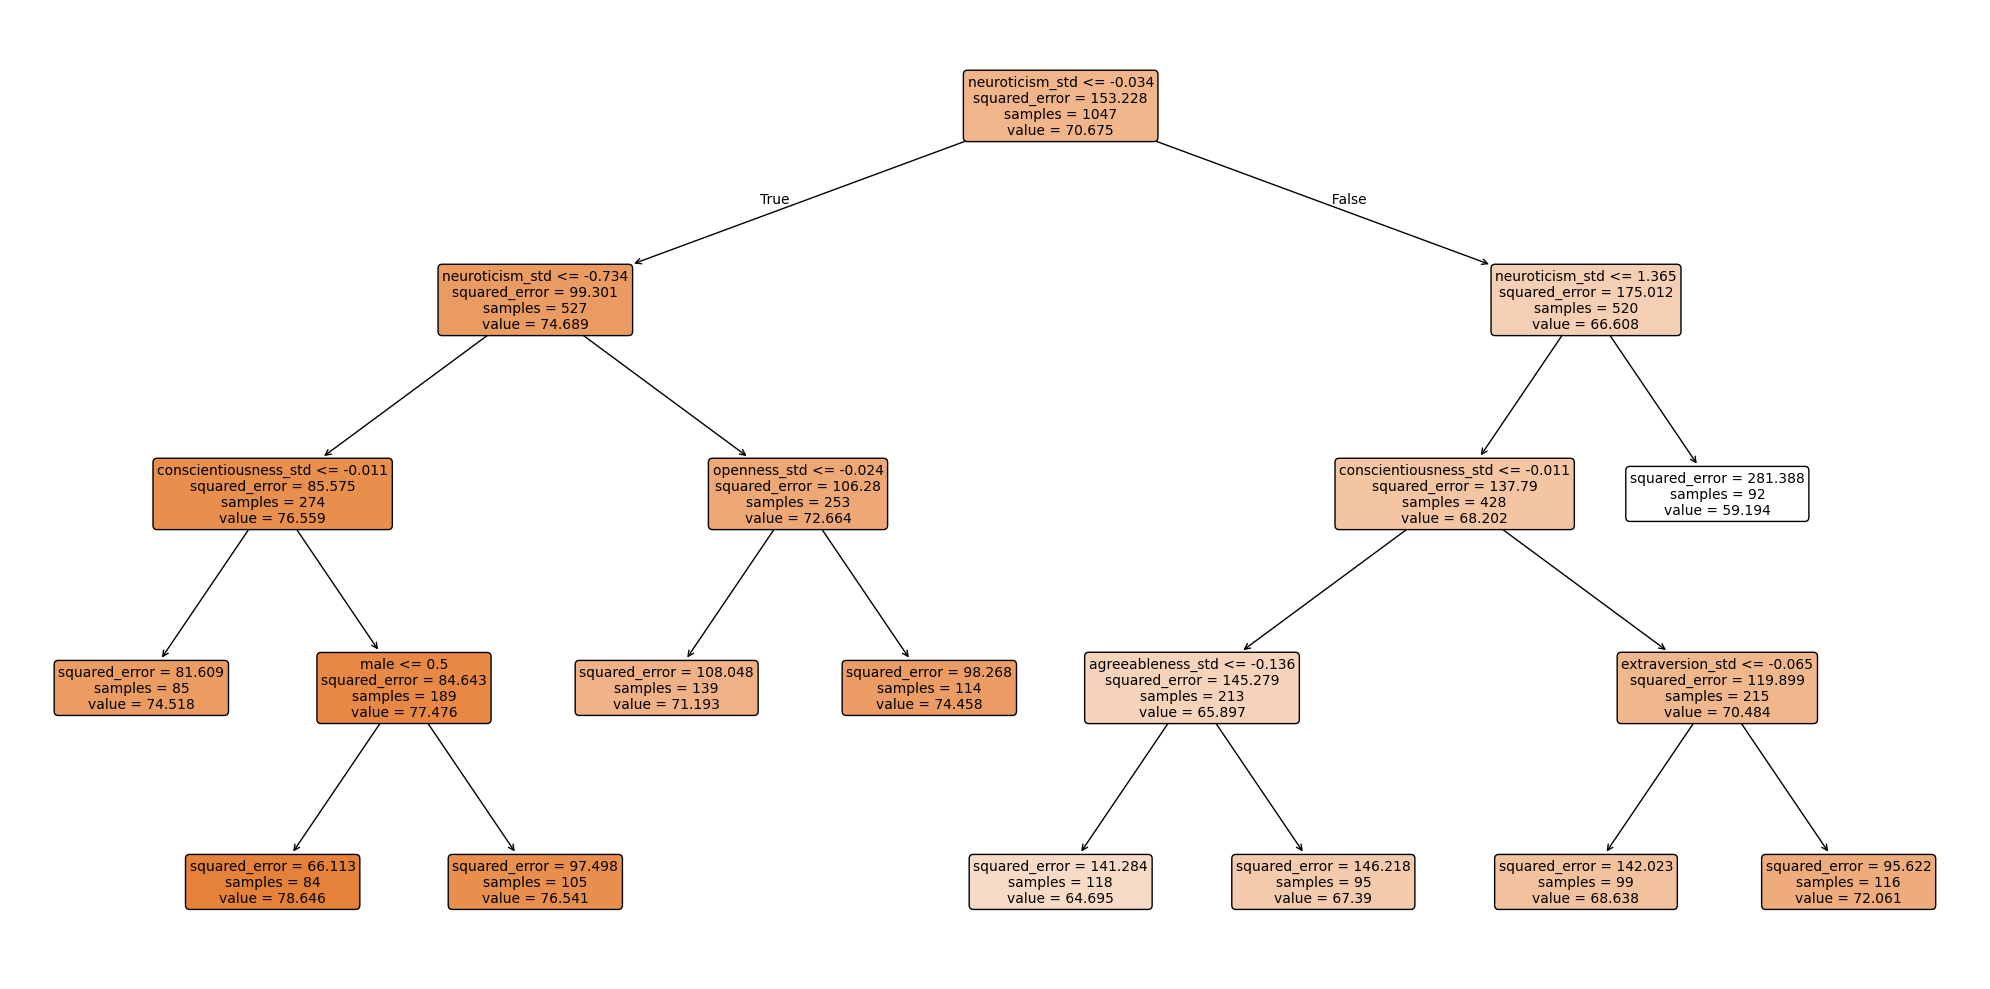

In [574]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model2,
          feature_names=features2,
          filled=True,
          rounded=True,
          fontsize=10)
plt.tight_layout()

In [575]:
print("Feature Importance:")
for feat, imp in zip(features2, tree_model2.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.022
  neuroticism_std: 0.844
  agreeableness_std: 0.013
  extraversion_std: 0.021
  conscientiousness_std: 0.093
  male: 0.007
  neduc: 0.000
  ueduc: 0.000
  oheduc: 0.000
  Alevel: 0.000
  gcse: 0.000
  otheduc: 0.000


purely classifying decision trees seperately by gender

In [576]:
features3 = traits

In [577]:
df_m = df[df['male'] == 1].copy()
df_f = df[df['male'] == 0].copy()

df_tree3 = df_m[features3 + [target]].dropna()
df_tree4 = df_f[features3 + [target]].dropna()

print("Male n:", len(df_m), "Female n:", len(df_f))

Male n: 457 Female n: 590


In [578]:
# Prepare X and y
X3 = df_tree3[features3]
y3 = df_tree3[target]

X4 = df_tree4[features3]
y4 = df_tree4[target]

male dec tree

In [579]:
tree_model3 = dtr(min_samples_leaf=38, criterion='squared_error', splitter='best',random_state=17)

In [580]:
tree_model3.fit(X3, y3)

DecisionTreeRegressor(min_samples_leaf=38, random_state=17)

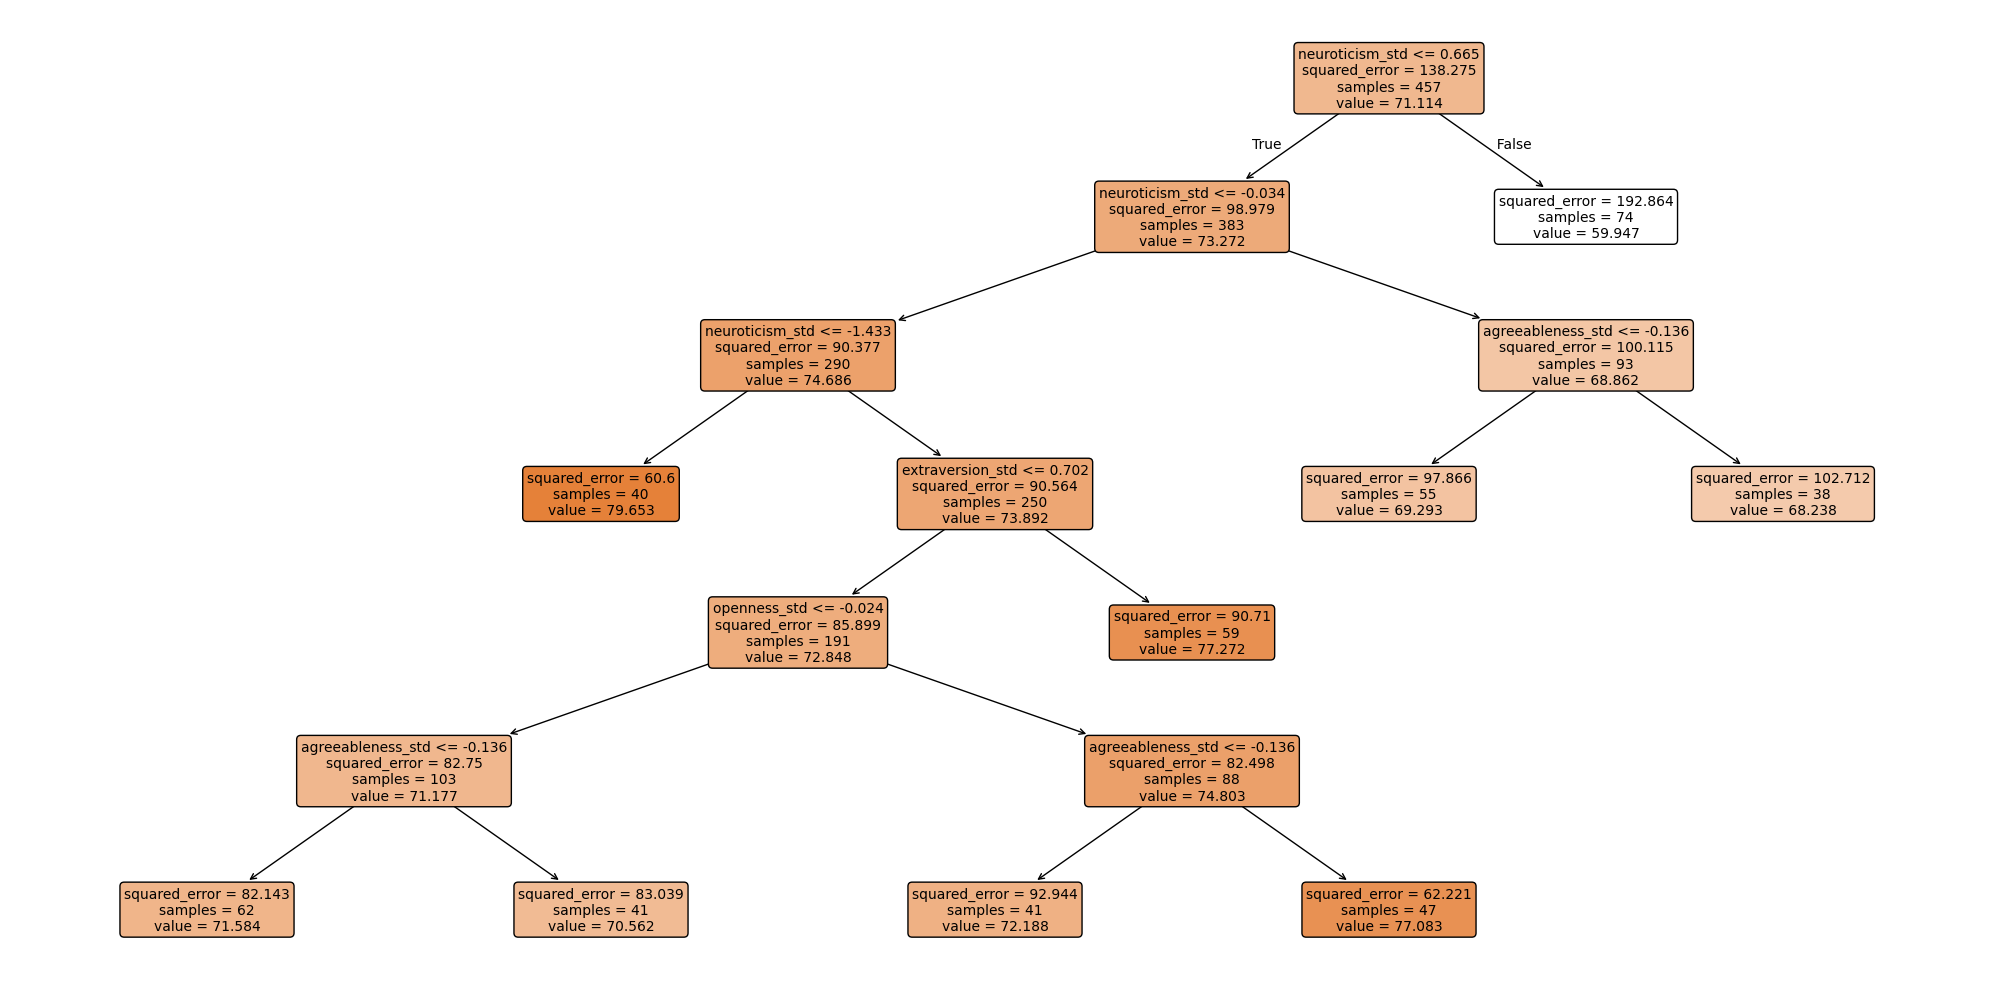

In [581]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model3,
          feature_names=features3,
          filled=True,
          rounded=True,
          fontsize=10)
plt.tight_layout()

In [582]:
print("Feature Importance:")
for feat, imp in zip(features3, tree_model3.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.038
  neuroticism_std: 0.875
  agreeableness_std: 0.035
  extraversion_std: 0.053
  conscientiousness_std: 0.000


female dec tree

In [583]:
tree_model4 = dtr(min_samples_leaf=38, criterion='squared_error', splitter='best',random_state=17)

In [584]:
tree_model4.fit(X4, y4)

DecisionTreeRegressor(min_samples_leaf=38, random_state=17)

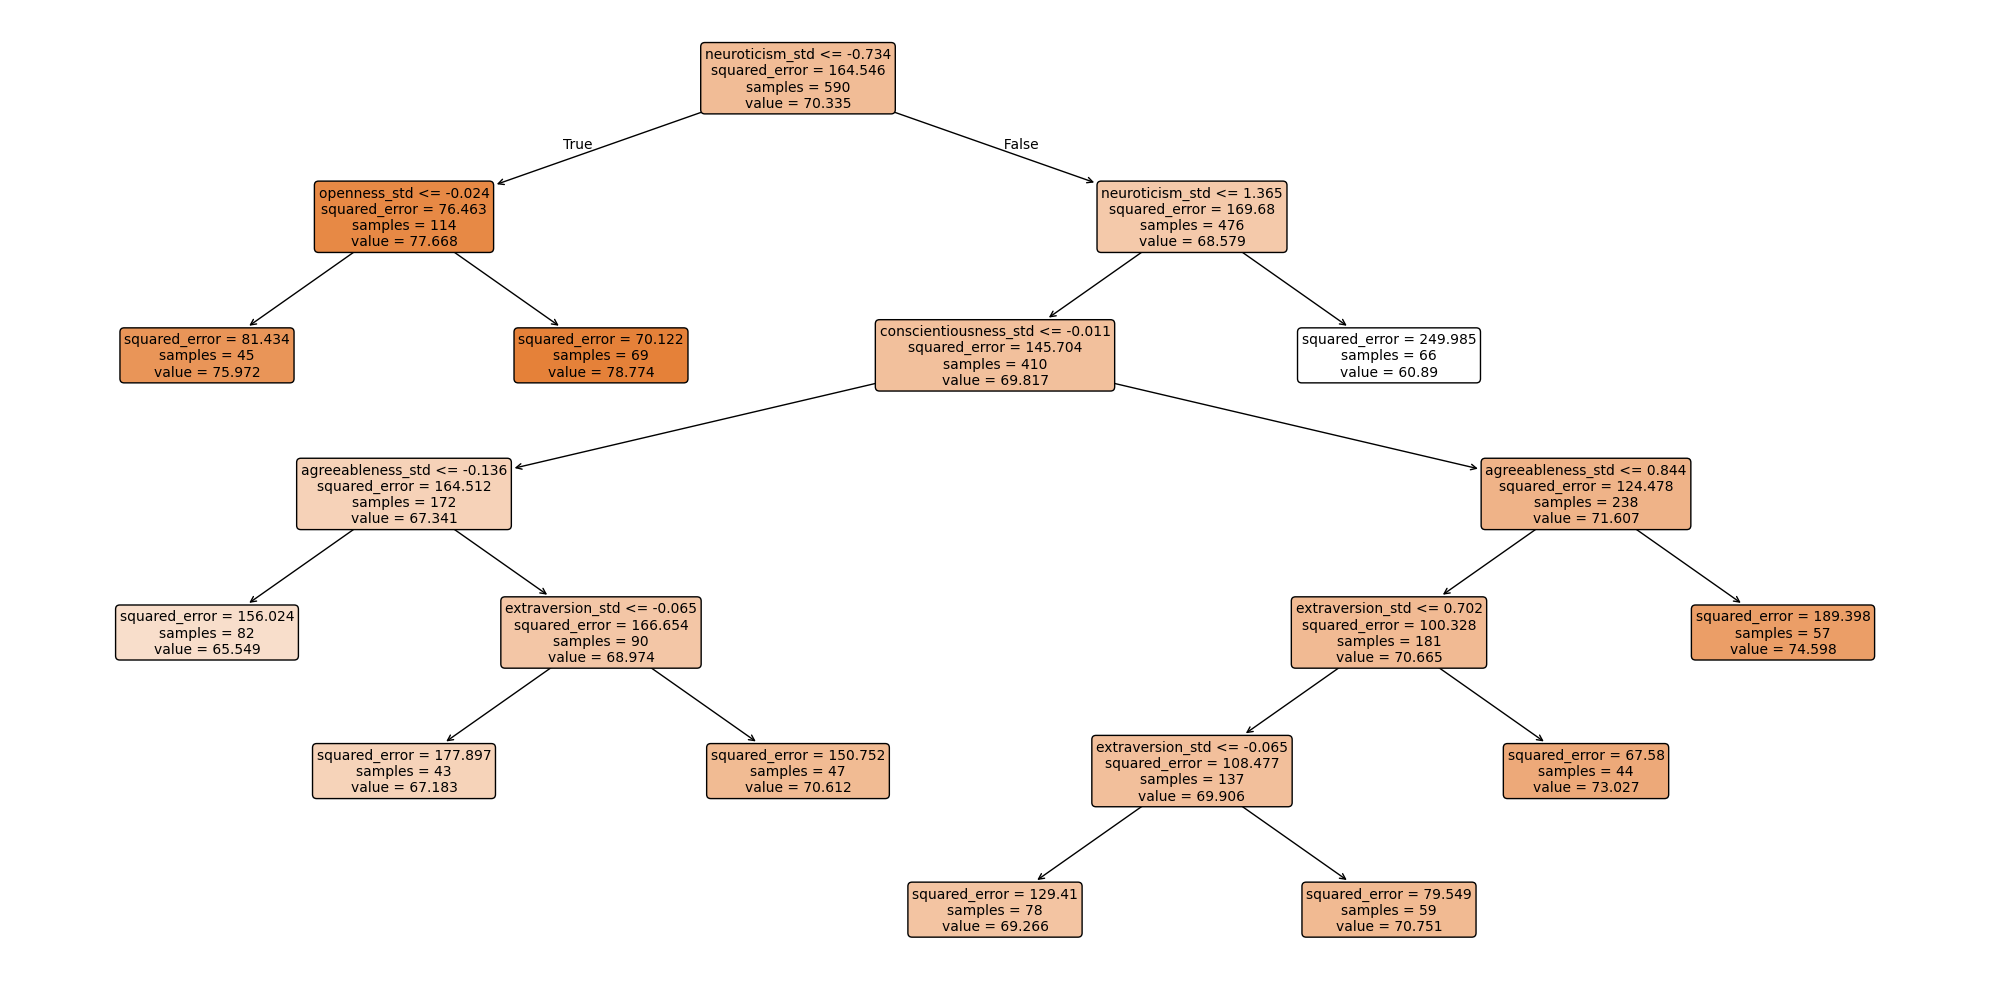

In [585]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model4,
          feature_names=features3,
          filled=True,
          rounded=True,
          fontsize=10)
plt.tight_layout()

In [586]:
print("Feature Importance:")
for feat, imp in zip(features3, tree_model4.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.013
  neuroticism_std: 0.758
  agreeableness_std: 0.073
  extraversion_std: 0.041
  conscientiousness_std: 0.114
